In [11]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.3.4


In [12]:
# Load datasets
train_df = pd.read_csv('../../data/raw/train.csv')
test_df = pd.read_csv('../../data/raw/test.csv')

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"\nTraining data shape: {train_df.shape}")
print(f"  - Number of houses: {train_df.shape[0]}")
print(f"  - Number of features: {train_df.shape[1]}")

print(f"\nTest data shape: {test_df.shape}")
print(f"  - Number of houses: {test_df.shape[0]}")
print(f"  - Number of features: {test_df.shape[1]}")


DATASET LOADED SUCCESSFULLY

Training data shape: (1460, 81)
  - Number of houses: 1460
  - Number of features: 81

Test data shape: (1459, 80)
  - Number of houses: 1459
  - Number of features: 80


In [13]:
# Display first few rows
print("First 5 rows of training data:")
print("=" * 100)
display(train_df.head())

print("\nColumn names and data types:")
print("=" * 100)
display(train_df.info())


First 5 rows of training data:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 no

None

In [14]:
# Statistical summary
print("Statistical Summary of Numerical Features:")
print("=" * 100)
display(train_df.describe())

print("\nTarget Variable (SalePrice) Statistics:")
print("=" * 50)
print(f"Mean Price: ${train_df['SalePrice'].mean():,.2f}")
print(f"Median Price: ${train_df['SalePrice'].median():,.2f}")
print(f"Min Price: ${train_df['SalePrice'].min():,.2f}")
print(f"Max Price: ${train_df['SalePrice'].max():,.2f}")
print(f"Standard Deviation: ${train_df['SalePrice'].std():,.2f}")


Statistical Summary of Numerical Features:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



Target Variable (SalePrice) Statistics:
Mean Price: $180,921.20
Median Price: $163,000.00
Min Price: $34,900.00
Max Price: $755,000.00
Standard Deviation: $79,442.50


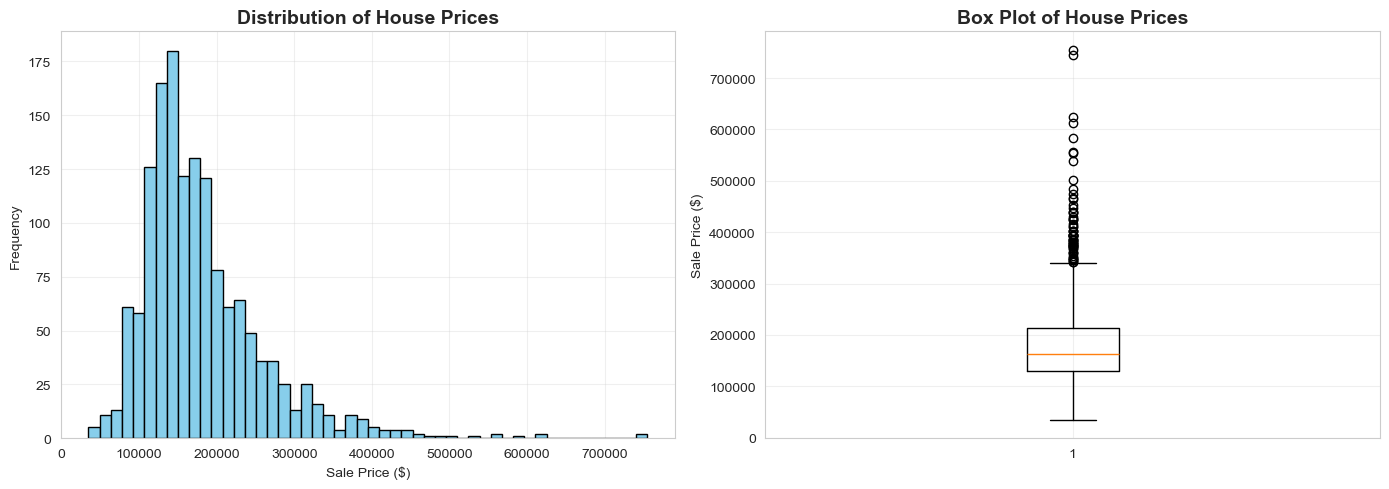

✓ Visualization saved to 'visualizations/price_distribution.png'


In [15]:
# Distribution of SalePrice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_df['SalePrice'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of House Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(train_df['SalePrice'], vert=True)
axes[1].set_title('Box Plot of House Prices', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Sale Price ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../visualizations/price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to 'visualizations/price_distribution.png'")


Columns with Missing Values:


,Missing_Count,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageYrBlt,81,5.547945
GarageCond,81,5.547945
GarageType,81,5.547945


<Figure size 1200x800 with 0 Axes>

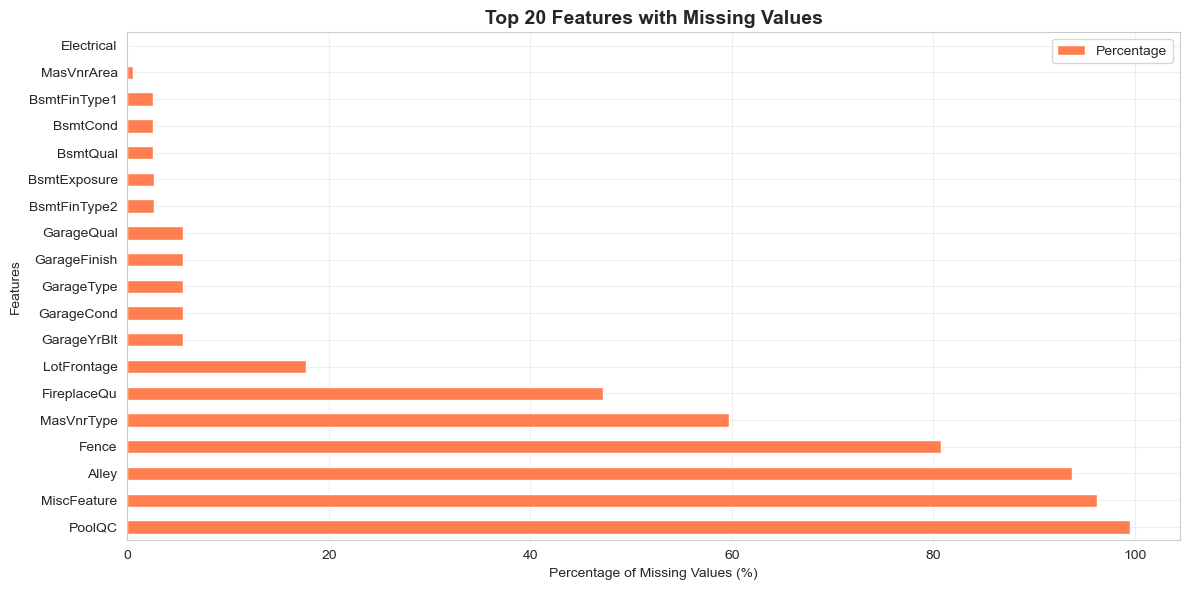


✓ Visualization saved to 'visualizations/missing_values.png'


In [16]:
# Missing values analysis
missing_data = train_df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_data / len(train_df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percentage': missing_percent
})

# Show only columns with missing values
missing_df = missing_df[missing_df['Missing_Count'] > 0]

print("Columns with Missing Values:")
print("=" * 60)
display(missing_df)

# Visualize missing data
plt.figure(figsize=(12, 8))
missing_df.head(20).plot(kind='barh', y='Percentage', color='coral')
plt.title('Top 20 Features with Missing Values', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Features')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../visualizations/missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to 'visualizations/missing_values.png'")


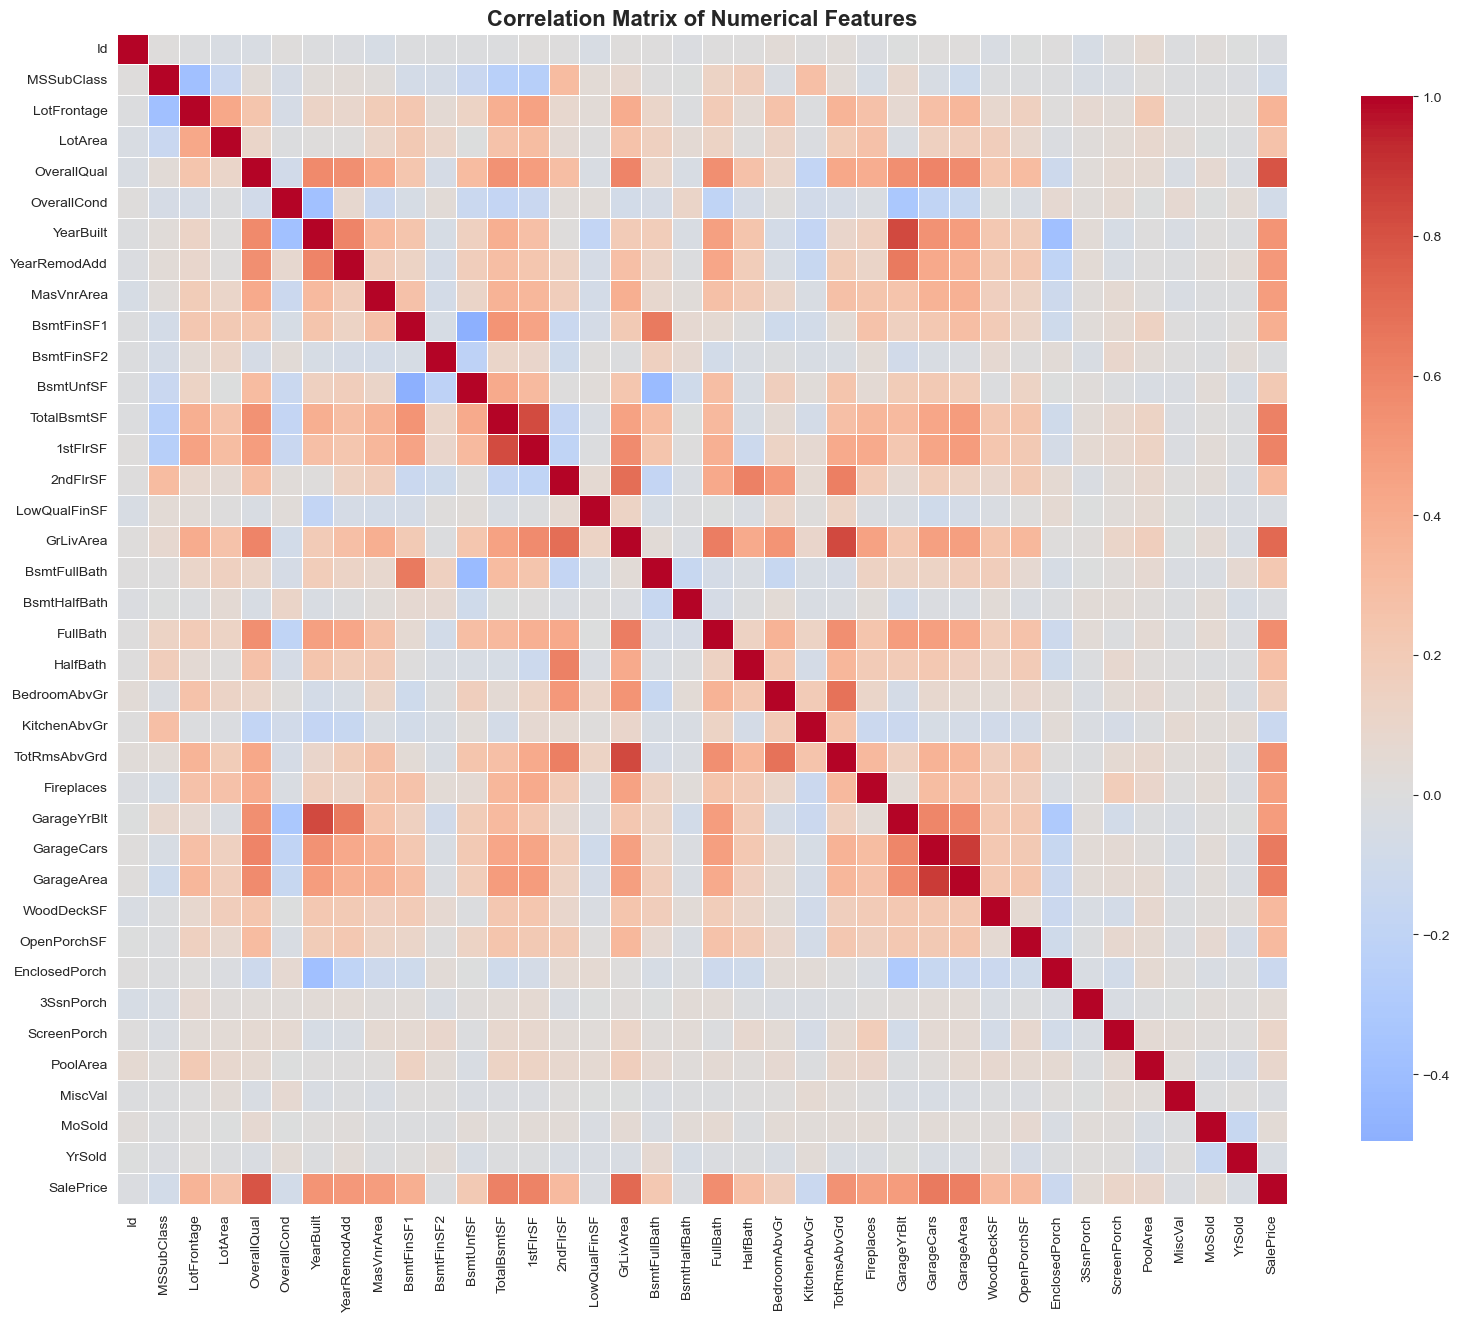

✓ Visualization saved to 'visualizations/correlation_matrix.png'


In [17]:
# Select only numerical features
numerical_features = train_df.select_dtypes(include=[np.number])

# Calculate correlation matrix
correlation_matrix = numerical_features.corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, 
            annot=False, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../../visualizations/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to 'visualizations/correlation_matrix.png'")


Top 15 Features Most Correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

Bottom 10 Features (Negative Correlation):
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


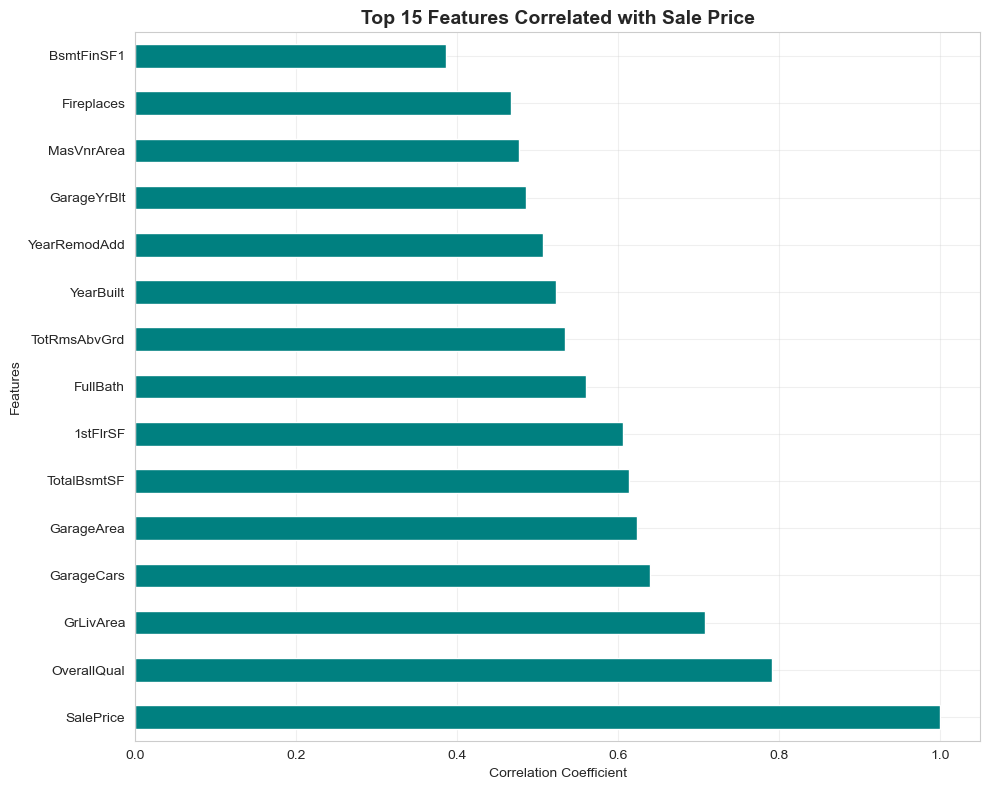


✓ Visualization saved to 'visualizations/top_correlations.png'


In [18]:
# Find top features correlated with SalePrice
sale_price_corr = correlation_matrix['SalePrice'].sort_values(ascending=False)

print("Top 15 Features Most Correlated with SalePrice:")
print("=" * 60)
print(sale_price_corr.head(15))

print("\n" + "=" * 60)
print("Bottom 10 Features (Negative Correlation):")
print("=" * 60)
print(sale_price_corr.tail(10))

# Visualize top correlations
plt.figure(figsize=(10, 8))
sale_price_corr.head(15).plot(kind='barh', color='teal')
plt.title('Top 15 Features Correlated with Sale Price', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../visualizations/top_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to 'visualizations/top_correlations.png'")


In [19]:
# Identify categorical features
categorical_features = train_df.select_dtypes(include=['object']).columns

print(f"Number of Categorical Features: {len(categorical_features)}")
print("=" * 60)
print("\nCategorical Features:")
for i, col in enumerate(categorical_features, 1):
    unique_count = train_df[col].nunique()
    print(f"{i}. {col}: {unique_count} unique values")


Number of Categorical Features: 43

Categorical Features:
1. MSZoning: 5 unique values
2. Street: 2 unique values
3. Alley: 2 unique values
4. LotShape: 4 unique values
5. LandContour: 4 unique values
6. Utilities: 2 unique values
7. LotConfig: 5 unique values
8. LandSlope: 3 unique values
9. Neighborhood: 25 unique values
10. Condition1: 9 unique values
11. Condition2: 8 unique values
12. BldgType: 5 unique values
13. HouseStyle: 8 unique values
14. RoofStyle: 6 unique values
15. RoofMatl: 8 unique values
16. Exterior1st: 15 unique values
17. Exterior2nd: 16 unique values
18. MasVnrType: 3 unique values
19. ExterQual: 4 unique values
20. ExterCond: 5 unique values
21. Foundation: 6 unique values
22. BsmtQual: 4 unique values
23. BsmtCond: 4 unique values
24. BsmtExposure: 4 unique values
25. BsmtFinType1: 6 unique values
26. BsmtFinType2: 6 unique values
27. Heating: 6 unique values
28. HeatingQC: 5 unique values
29. CentralAir: 2 unique values
30. Electrical: 5 unique values
31. Kitc

In [20]:
# Create a summary report
summary = {
    'Total Rows (Train)': train_df.shape[0],
    'Total Rows (Test)': test_df.shape[0],
    'Total Features': train_df.shape[1],
    'Numerical Features': len(numerical_features.columns),
    'Categorical Features': len(categorical_features),
    'Features with Missing Values': len(missing_df),
    'Average Sale Price': f"${train_df['SalePrice'].mean():,.2f}",
    'Median Sale Price': f"${train_df['SalePrice'].median():,.2f}"
}

summary_df = pd.DataFrame(summary.items(), columns=['Metric', 'Value'])
display(summary_df)

# Save to CSV
summary_df.to_csv('../../data/processed/exploration_summary.csv', index=False)
print("\n✓ Summary saved to 'data/processed/exploration_summary.csv'")

print("\n" + "=" * 60)
print("✅ DATA EXPLORATION COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\nNext Steps:")
print("1. Review all visualizations in the 'visualizations' folder")
print("2. Open notebook: 02_data_preprocessing.ipynb")
print("3. Start data cleaning and feature engineering")


,Metric,Value
0,Total Rows (Train),1460
1,Total Rows (Test),1459
2,Total Features,81
3,Numerical Features,38
4,Categorical Features,43
5,Features with Missing Values,19
6,Average Sale Price,"$180,921.20"
7,Median Sale Price,"$163,000.00"



✓ Summary saved to 'data/processed/exploration_summary.csv'

✅ DATA EXPLORATION COMPLETED SUCCESSFULLY!

Next Steps:
1. Review all visualizations in the 'visualizations' folder
2. Open notebook: 02_data_preprocessing.ipynb
3. Start data cleaning and feature engineering
